In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import os


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
import os

# Получаем путь к текущей папке, затем берем родительскую (корень проекта)
# '..' означает "на уровень выше"
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Добавляем корень в sys.path, если его там еще нет
if project_root not in sys.path:
    sys.path.append(project_root)

# Теперь Python видит папку pipeline как модуль
from pipeline.dataset import UrbanAirDataset

In [3]:
# Настройки
DATA_DIR = ['/app/urban-layer-datasets/2026_01_19_500_25d_data/', '/app/urban-layer-datasets/2026_01_27_500_25d_data/']
dataset = UrbanAirDataset(DATA_DIR, mode='val', log_target=False) # Берем val без аугментаций для чистоты

# Cбор статистики

In [23]:



stats = []

print(f"Collecting statistics for {len(dataset)} samples...")

for i in tqdm(range(len(dataset))):
    x, y = dataset[i]
    x = x.numpy()
    y = y.numpy()
    
    # --- Анализ Входа (X) ---
    build_h = x[0]
    lai = x[2]
    source_h = x[3]
    wind_x = x[4, 0, 0] # Они константные по полю
    wind_y = x[5, 0, 0]
    # wind_x = x[5, 0, 0] # Они константные по полю
    # wind_y = x[6, 0, 0]
    
    # 1. Геометрия
    building_density = np.mean(build_h > 0) # % застройки
    avg_build_h = build_h[build_h > 0].mean() if np.any(build_h > 0) else 0
    max_build_h = build_h.max()
    
    # 2. Ветер
    wind_speed = np.sqrt(wind_x**2 + wind_y**2)
    wind_angle = np.degrees(np.arctan2(wind_y, wind_x))
    
    # 3. Растительность
    tree_density = np.mean(lai > 0)
    total_lai = np.sum(lai)
    
    # 4. Источники
    source_count = np.sum(source_h > 0) # количество "пикселей" дороги
    
    # --- Анализ Выхода (Y) ---
    # Берем слой Z1 (земля) как самый важный
    max_conc = y[0].max()
    mean_conc = y[0].mean()
    area_polluted = np.mean(y[0] > 1e-3) # % площади с заметным загрязнением
    stats.append({
        'filename': os.path.basename(dataset.files[i]),
        'build_density': building_density,
        'avg_build_h': avg_build_h,
        'max_build_h': max_build_h,
        'wind_speed': wind_speed,
        'wind_angle': wind_angle,
        'tree_density': tree_density,
        'source_pixels': source_count,
        'max_conc_z1': y[0].max(),
        'mean_conc_z1': y[0].mean(),
        
        'max_conc_z5': y[1].max(),
        'mean_conc_z5': y[1].mean(),
        
        'max_conc_z8': y[2].max(),
        'mean_conc_z8': y[2].mean(),
        
        'max_conc_z25': y[3].max(),
        'mean_conc_z25': y[3].mean(),
        
        'max_conc_mean': y[4].max(),
        'mean_conc_mean': y[4].mean(),
        
        'polluted_area_ratio': area_polluted
    })

df = pd.DataFrame(stats)
df.head()

100%|██████████| 6356/6356 [00:19<00:00, 325.00it/s]


,filename,build_density,avg_build_h,max_build_h,wind_speed,wind_angle,tree_density,source_pixels,max_conc_z1,mean_conc_z1,max_conc_z5,mean_conc_z5,max_conc_z8,mean_conc_z8,max_conc_z25,mean_conc_z25,max_conc_mean,mean_conc_mean,polluted_area_ratio
0,2026_01_19_500_25d__output_2026_1_15_21_51_16_...,0.0625,0.21875,0.21875,0.000251,31.667213,0.165527,192,4474.825195,637.204102,2069.695312,560.570923,898.930481,546.911133,468.181274,457.021118,1150.292480,509.296875,0.9375
1,2026_01_27_500_25d__output_2026_1_25_3_39_31__...,0.0625,0.21875,0.21875,0.000251,112.479424,0.052002,1108,33331.250000,8949.562500,15883.375000,8014.739746,10833.346680,7988.357422,6916.578613,6762.178711,10985.746094,7426.537598,0.9375
2,2026_01_19_500_25d__output_2026_1_11_17_52_17_...,0.0625,0.21875,0.21875,0.000251,2.737157,0.056396,567,31294.541016,11234.883789,19138.841797,10193.253906,13505.582031,10155.599609,8798.077148,8596.230469,13002.662109,9421.458008,0.9375
3,2026_01_19_500_25d__output_2026_1_12_15_40_7__...,0.0625,0.21875,0.21875,0.000249,-93.921394,0.042297,128,562.155823,60.126328,258.585419,54.264946,105.618591,53.728729,53.291271,45.999722,132.303467,50.203522,0.9375
4,2026_01_27_500_25d__output_2026_1_20_20_5_38__...,0.0625,0.21875,0.21875,0.000249,-111.417160,0.069580,636,40062.675781,11794.496094,19452.529297,10427.264648,13871.222656,10281.244141,8967.287109,8749.160156,13738.237305,9624.842773,0.9375


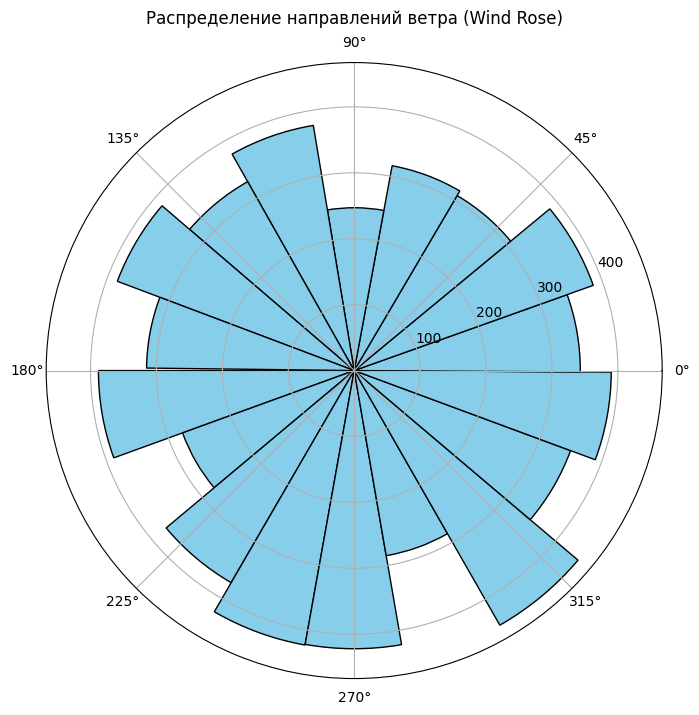

Диапазон скоростей ветра: 0.0002 - 0.0003


In [5]:
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')
# Группируем углы по 20 градусов
angles = np.radians(df['wind_angle'])
ax.hist(angles, bins=18, color='skyblue', edgecolor='black')
ax.set_title("Распределение направлений ветра (Wind Rose)", va='bottom')
plt.show()

print(f"Диапазон скоростей ветра: {df['wind_speed'].min():.4f} - {df['wind_speed'].max():.4f}")

In [21]:
print(df.nunique())

filename               6356
build_density             1
avg_build_h               1
max_build_h               1
wind_speed              496
wind_angle              739
tree_density            839
source_pixels           247
max_conc               6350
mean_conc              6351
polluted_area_ratio       1
dtype: int64


In [22]:
df['polluted_area_ratio']

0       0.9375
1       0.9375
2       0.9375
3       0.9375
4       0.9375
         ...  
6351    0.9375
6352    0.9375
6353    0.9375
6354    0.9375
6355    0.9375
Name: polluted_area_ratio, Length: 6356, dtype: float64

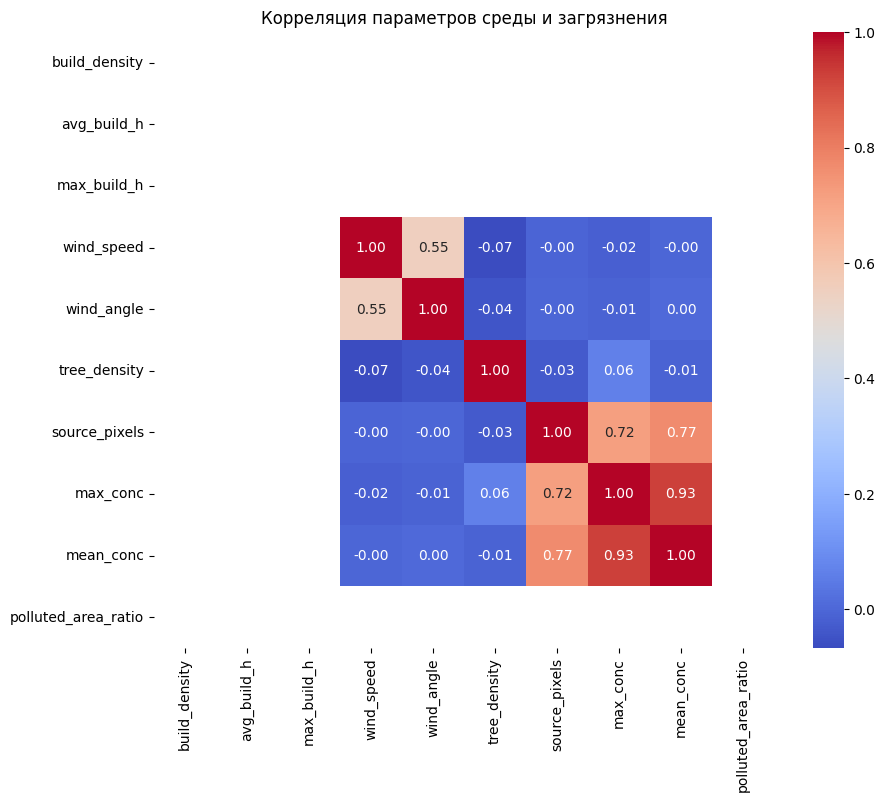

In [8]:
plt.figure(figsize=(10, 8))
# Считаем корреляцию Пирсона
corr = df.drop(columns=['filename']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция параметров среды и загрязнения")
plt.show()

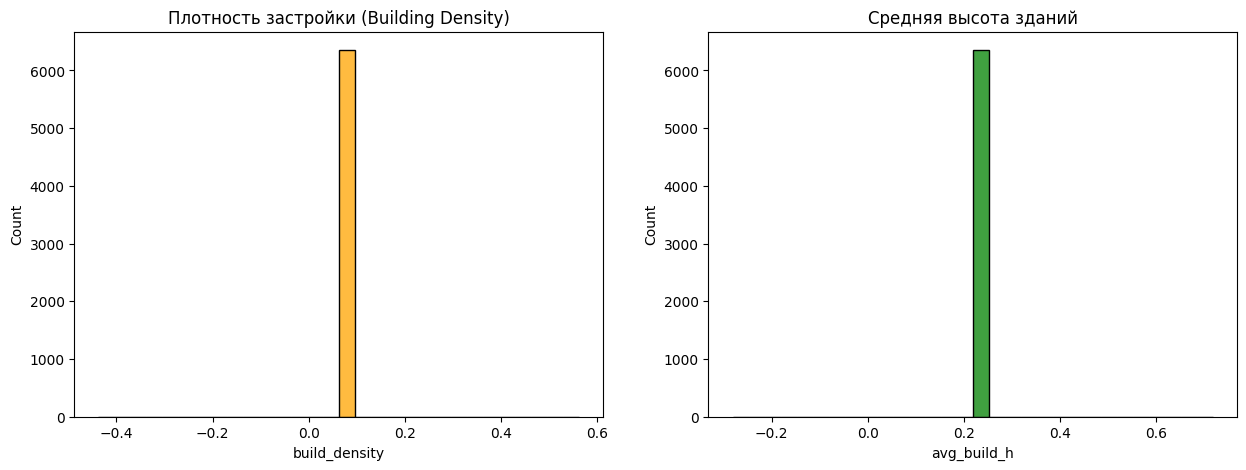

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['build_density'], bins=30, ax=axes[0], color='orange')
axes[0].set_title("Плотность застройки (Building Density)")

sns.histplot(df['avg_build_h'], bins=30, ax=axes[1], color='green')
axes[1].set_title("Средняя высота зданий")

plt.show()

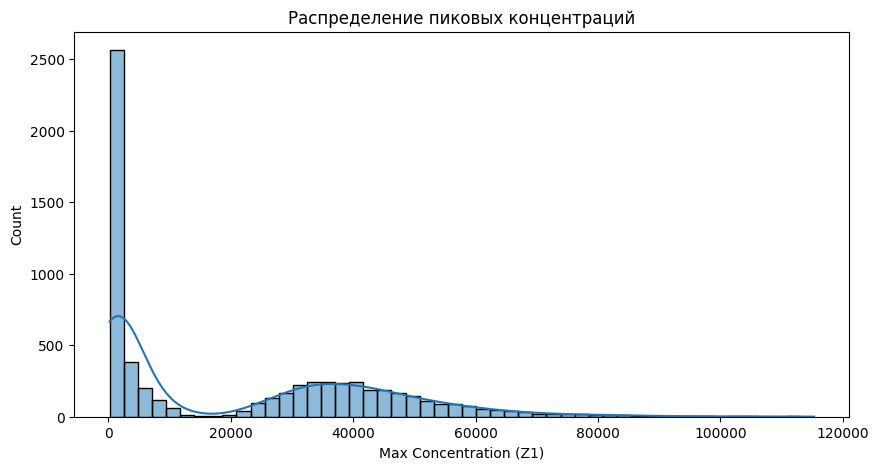

95-й перцентиль концентрации: 60122.17


In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['max_conc_z1'], bins=50, kde=True)
# plt.yscale('log') # Логарифмическая шкала важна!
plt.title("Распределение пиковых концентраций")
plt.xlabel("Max Concentration (Z1)")
plt.show()

print(f"95-й перцентиль концентрации: {df['max_conc_z1'].quantile(0.95):.2f}")

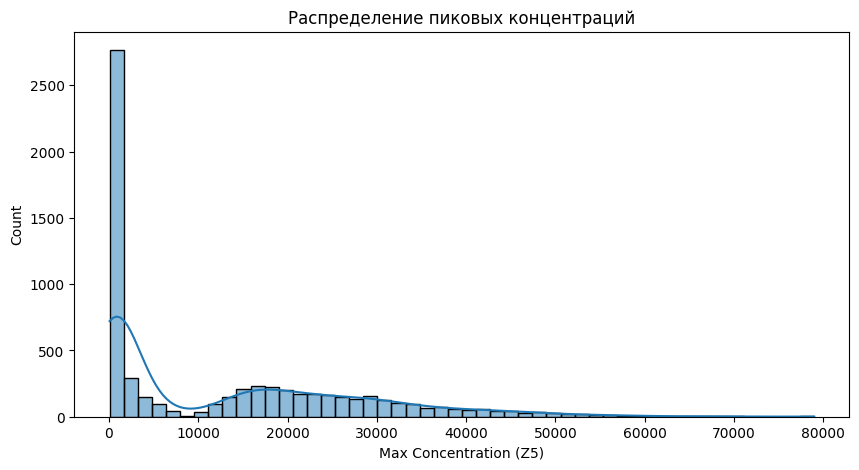

95-й перцентиль концентрации: 41764.35


In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df['max_conc_z5'], bins=50, kde=True)
# plt.yscale('log') # Логарифмическая шкала важна!
plt.title("Распределение пиковых концентраций")
plt.xlabel("Max Concentration (Z5)")
plt.show()

print(f"95-й перцентиль концентрации: {df['max_conc_z5'].quantile(0.95):.2f}")

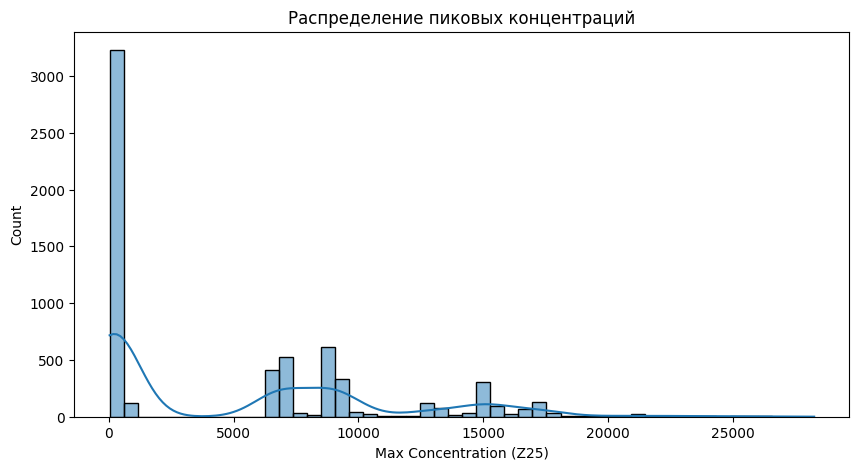

95-й перцентиль концентрации: 16550.99


In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(df['max_conc_z25'], bins=50, kde=True)
# plt.yscale('log') # Логарифмическая шкала важна!
plt.title("Распределение пиковых концентраций")
plt.xlabel("Max Concentration (Z25)")
plt.show()

print(f"95-й перцентиль концентрации: {df['max_conc_z25'].quantile(0.95):.2f}")

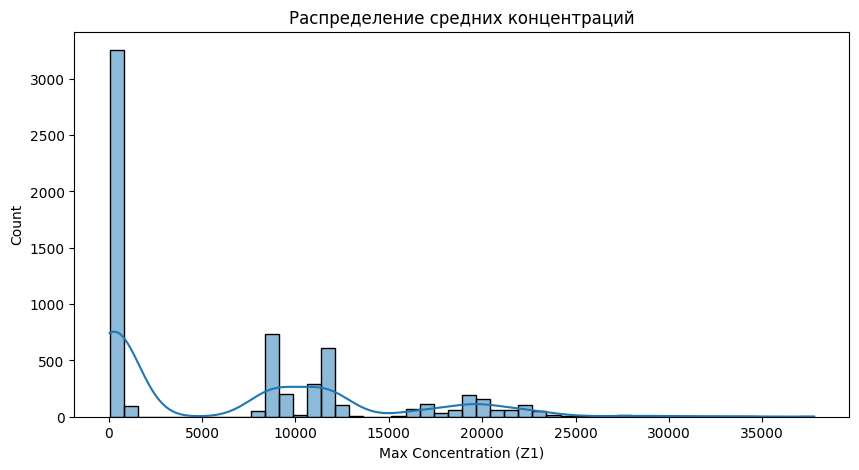

95-й перцентиль концентрации: 20916.14


In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['mean_conc'], bins=50, kde=True)
# plt.yscale('log') # Логарифмическая шкала важна!
plt.title("Распределение средних концентраций")
plt.xlabel("Max Concentration (Z1)")
plt.show()

print(f"95-й перцентиль концентрации: {df['mean_conc'].quantile(0.95):.2f}")

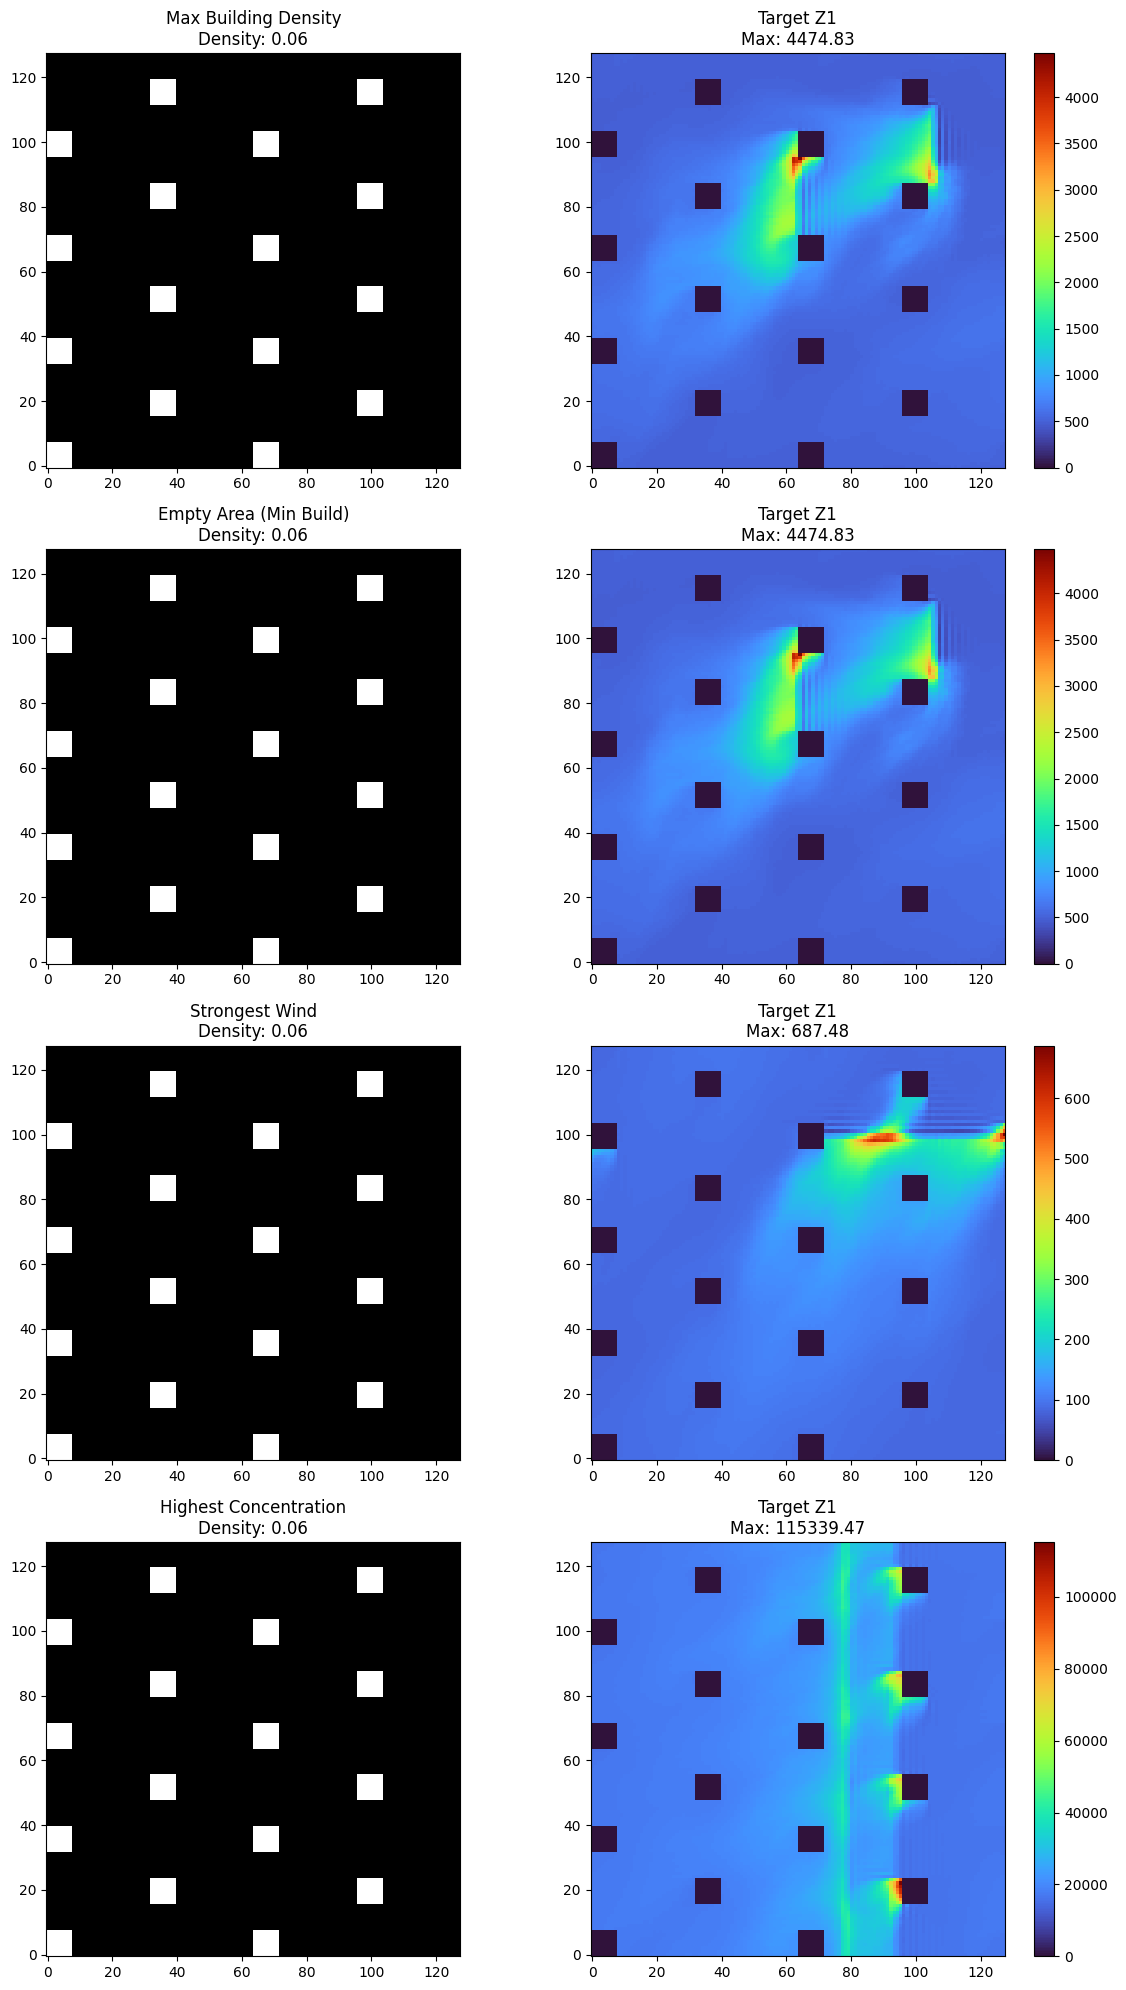

In [14]:
# Находим индексы самых интересных кейсов
idx_max_build = df['build_density'].idxmax()
idx_min_build = df['build_density'].idxmin()
idx_max_wind = df['wind_speed'].idxmax()
idx_max_conc = df['max_conc'].idxmax()

cases = [
    ("Max Building Density", idx_max_build),
    ("Empty Area (Min Build)", idx_min_build),
    ("Strongest Wind", idx_max_wind),
    ("Highest Concentration", idx_max_conc)
]

fig, axes = plt.subplots(len(cases), 2, figsize=(12, 5 * len(cases)))

for i, (title, idx) in enumerate(cases):
    x, y = dataset[idx]
    
    # Отрисовка зданий и ветра
    axes[i, 0].imshow(x[0], cmap='bone', origin='lower')
    axes[i, 0].set_title(f"{title}\nDensity: {df.loc[idx, 'build_density']:.2f}")
    
    # Отрисовка концентрации
    im = axes[i, 1].imshow(y[0], cmap='turbo', origin='lower')
    axes[i, 1].set_title(f"Target Z1\nMax: {y[0].max():.2f}")
    plt.colorbar(im, ax=axes[i, 1])

plt.tight_layout()
plt.show()